## A baseline MLP model

In [1]:
# import plotnine as p9
# import numpy as np
import contextlib

import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd
import copy


# import torch


#### Read and prepare data

In [2]:
harv = pd.read_csv('../data/harv_clean.csv')
stei = pd.read_csv('../data/stei_clean.csv')
df = harv

In [3]:
features = ['TA_F', 'VPD_F', 'P_F', 'GPP_NT_VUT_REF']
target_col = 'RECO_NT_VUT_REF'

# Drop rows with NaNs in features or target
df_model = df.dropna(subset=features + [target_col, 'year']).copy()

years = sorted(df_model['year'].unique())
print("Years in dataset:", years)

Years in dataset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [4]:
df.shape

(81705, 45)

In [5]:
# -------------------------
# 2. Define MLP model
# -------------------------
class MLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_hidden_layers=5):
        super().__init__()
        layers = []
        # first layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        # hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        # output layer
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [6]:
# -------------------------
# 3. Training & evaluation helpers
# -------------------------
def train_one_fold(
    model,
    train_loader,
    X_val,
    y_val,
    num_epochs=100,
    lr=1e-4,
    device='cpu',
    patience=10,      # 🔸 how many epochs with no improvement before stopping
    min_delta=0.0     # 🔸 minimum change to count as "improvement"
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Move validation data to tensors on device
    X_val_tensor = torch.from_numpy(X_val.astype(np.float32)).to(device)
    y_val_tensor = torch.from_numpy(y_val.astype(np.float32)).to(device)

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        train_loss = running_loss / n_samples

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_tensor).squeeze()
            val_loss = criterion(val_preds, y_val_tensor).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        # ---- Early stopping logic ----
        if val_loss + min_delta < best_val_loss:
            # Improvement
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            # No improvement
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"⏹ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    # Load best model weights (lowest val_loss)
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return history


def predict_model(model, X, device='cpu'):
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.from_numpy(X.astype(np.float32)).to(device))
    return y_pred.cpu().numpy().squeeze()


In [7]:
# -------------------------
# 4. Cross-validation: leave-one-year-out
# -------------------------
from sklearn.metrics import r2_score  # if you want to use sklearn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_r2 = {}
fold_histories = {}
train_preds = {}  # year -> (y_train, y_pred_train)
test_preds  = {}  # year -> (y_test,  y_pred_test)

for test_year in years:
    print(f"\n=== Fold: Test year = {test_year} ===")

    train_df = df_model[df_model['year'] != test_year]
    test_df  = df_model[df_model['year'] == test_year]

    X_train = train_df[features].values
    y_train = train_df[target_col].values
    X_test  = test_df[features].values
    y_test  = test_df[target_col].values

    # Standardize from training data only
    mean = X_train.mean(axis=0, keepdims=True)
    std  = X_train.std(axis=0, keepdims=True)
    std[std == 0] = 1.0

    X_train_norm = (X_train - mean) / std
    X_test_norm  = (X_test  - mean) / std

    # DataLoader
    train_ds = TensorDataset(
        torch.from_numpy(X_train_norm.astype(np.float32)),
        torch.from_numpy(y_train.astype(np.float32))
    )
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

    # Model
    model = MLP(input_dim=len(features), hidden_dim=64, num_hidden_layers=5).to(device)

    # Train + record history
    history = train_one_fold(
        model,
        train_loader,
        X_test_norm,
        y_test,
        num_epochs=100,
        lr=1e-4,
        device=device,
        patience=10,     #
        min_delta=1e-4    #
    )

    fold_histories[test_year] = history

    # 🔹 Evaluate on test set and store R²
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(X_test_norm.astype(np.float32)).to(device)
        X_train_tensor = torch.from_numpy(X_train_norm.astype(np.float32)).to(device)
        y_pred_test = model(X_test_tensor).cpu().numpy().ravel()
        y_pred_train = model(X_train_tensor).cpu().numpy().ravel()

    train_preds[test_year] = (y_train, y_pred_train)
    test_preds[test_year] = (y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    all_r2[test_year] = [r2_train,r2_test]
    # print(f"R² for test year {test_year}: {r2:.3f}")

print("\nR² by year:")
for y, r2s in all_r2.items():
    print(f"  Year {y}:  Train R² = {r2s[0]:.3f},   Test R² = {r2s[1]:.3f}")

print(f"\nMean R² across years: {np.mean(list(all_r2.values())):.3f}")


=== Fold: Test year = 2019 ===
Epoch 001 | train_loss=8.3985 | val_loss=3.8383
Epoch 002 | train_loss=1.4325 | val_loss=2.5311
Epoch 003 | train_loss=1.1606 | val_loss=2.5102
Epoch 004 | train_loss=1.1283 | val_loss=2.3472
Epoch 005 | train_loss=1.1151 | val_loss=2.2863
Epoch 006 | train_loss=1.1089 | val_loss=2.3770
Epoch 007 | train_loss=1.1024 | val_loss=2.2294
Epoch 008 | train_loss=1.0986 | val_loss=2.4208
Epoch 009 | train_loss=1.0947 | val_loss=2.4071
Epoch 010 | train_loss=1.0926 | val_loss=2.3793
Epoch 011 | train_loss=1.0905 | val_loss=2.2584
Epoch 012 | train_loss=1.0871 | val_loss=2.2391
Epoch 013 | train_loss=1.0846 | val_loss=2.5200
Epoch 014 | train_loss=1.0827 | val_loss=2.5348
Epoch 015 | train_loss=1.0829 | val_loss=2.4041
Epoch 016 | train_loss=1.0793 | val_loss=2.3759
Epoch 017 | train_loss=1.0768 | val_loss=2.2933
⏹ Early stopping at epoch 17 (no improvement for 10 epochs)

=== Fold: Test year = 2020 ===
Epoch 001 | train_loss=9.0458 | val_loss=1.4087
Epoch 002 | 

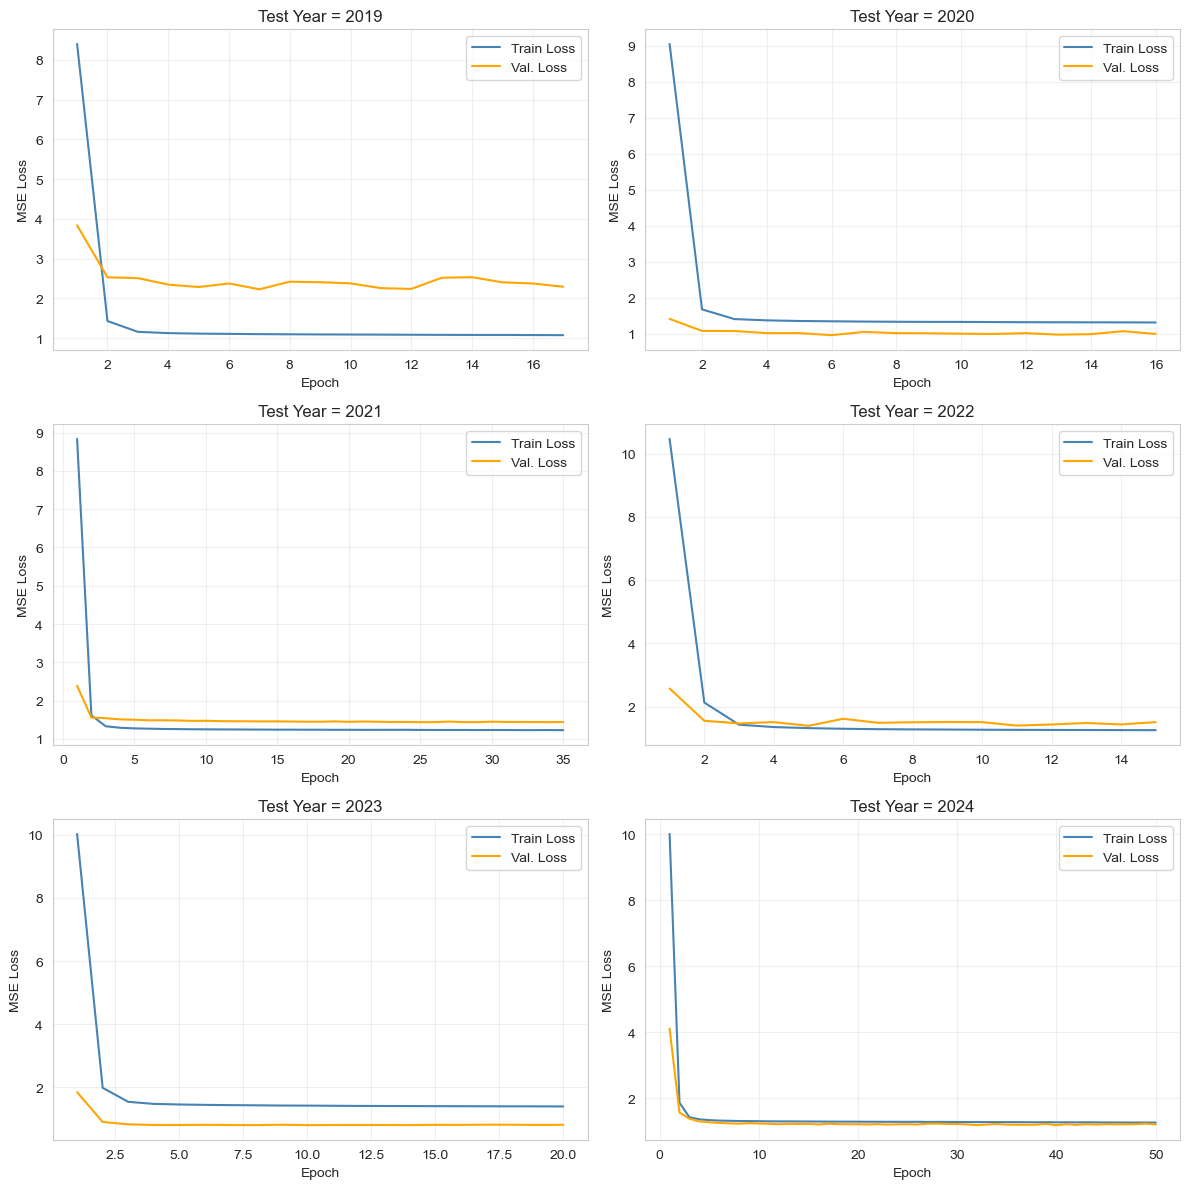

In [8]:
import matplotlib.pyplot as plt
import math

n = len(years)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=False)
axes = axes.flatten()

for i, test_year in enumerate(years):
    ax = axes[i]
    hist = fold_histories[test_year]

    epochs = range(1, len(hist["train_loss"]) + 1)

    ax.plot(epochs, hist["train_loss"], label="Train Loss", color="steelblue")
    ax.plot(epochs, hist["val_loss"],  label="Val. Loss",  color="orange")

    ax.set_title(f"Test Year = {test_year}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.grid(alpha=0.3)
    ax.legend()

# remove empty axes if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

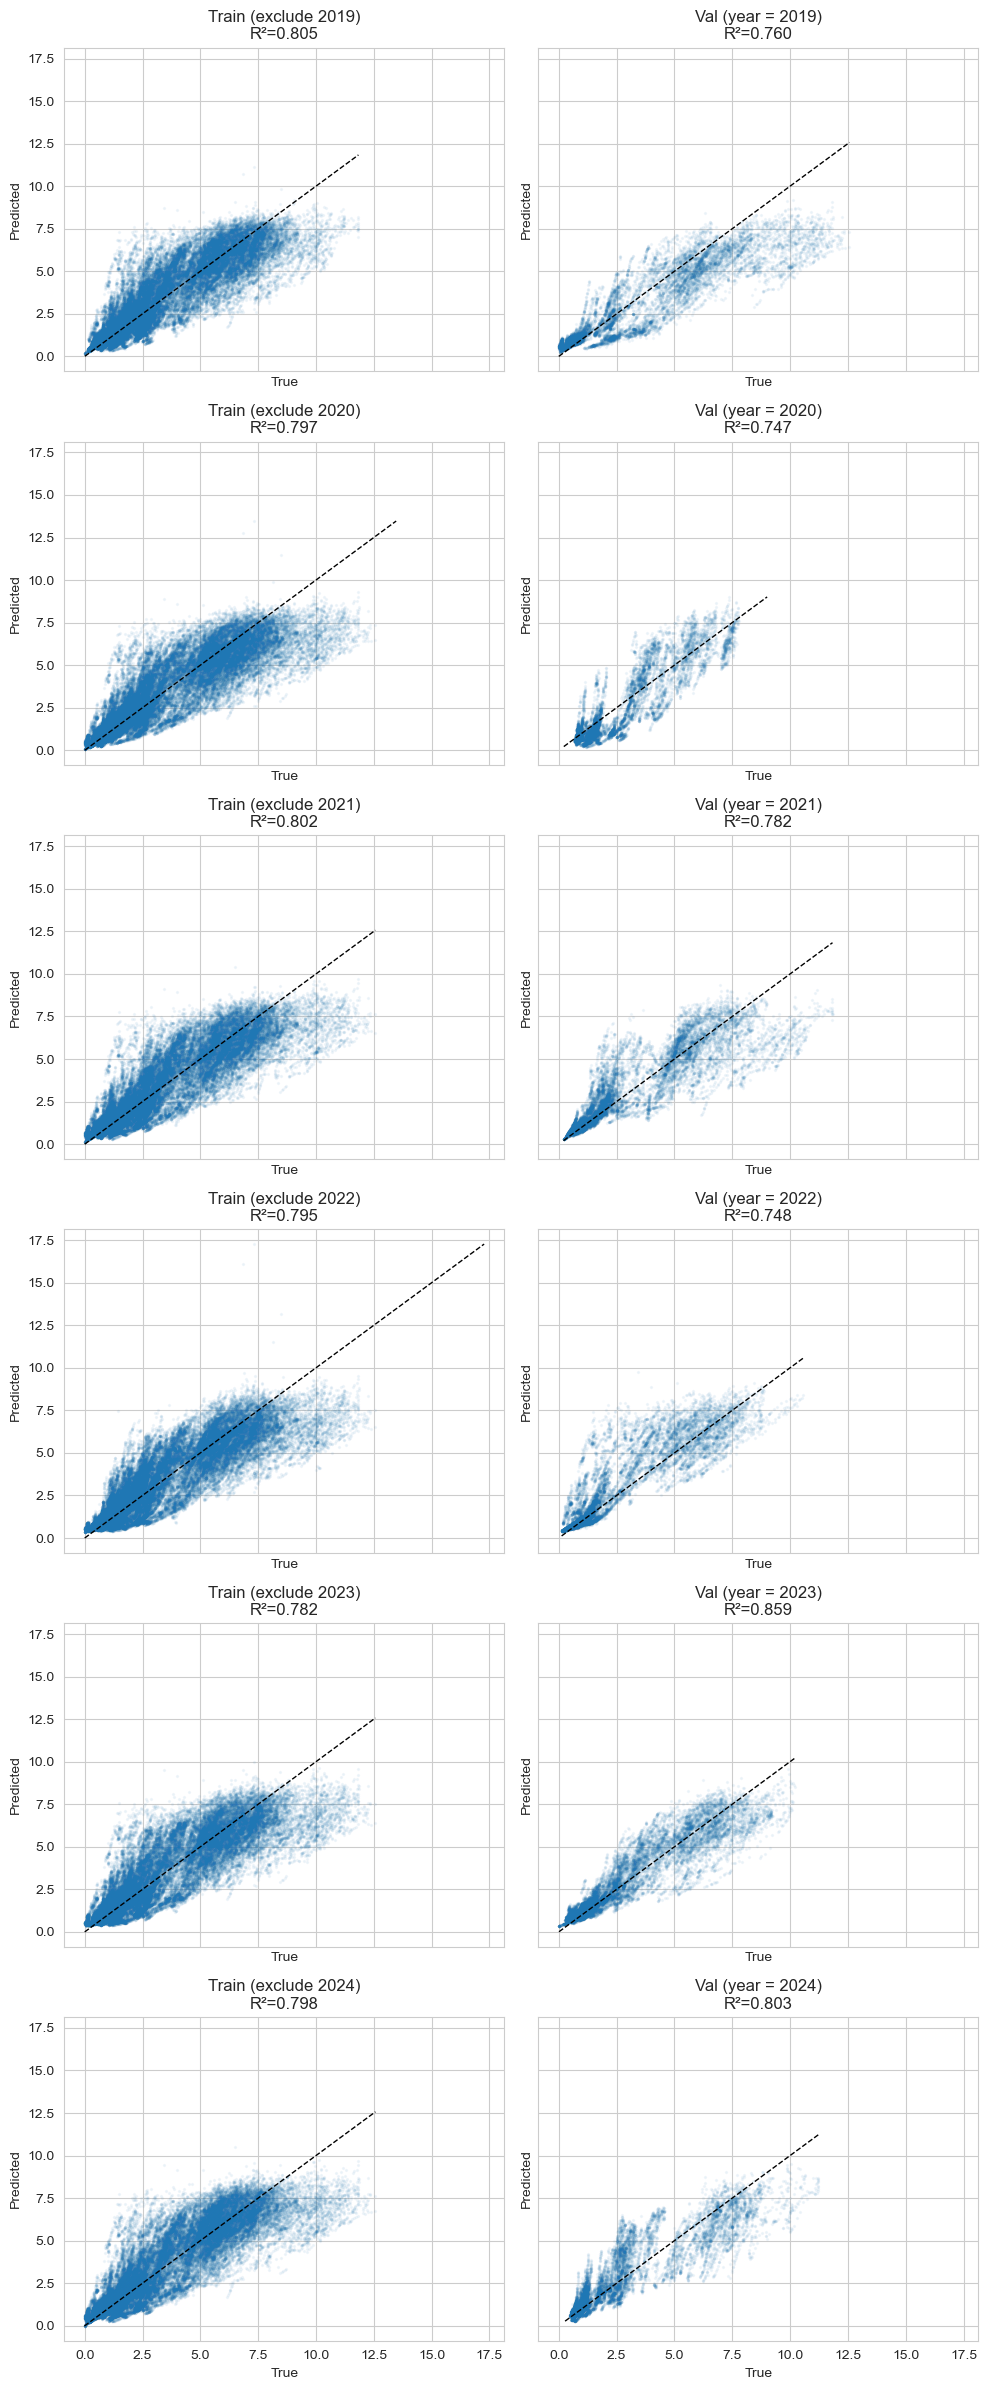

In [9]:
years_list = list(years)
n_years = len(years_list)

fig, axes = plt.subplots(n_years, 2, figsize=(10, 4 * n_years), sharex=True, sharey=True)

# Handle case n_years == 1 (axes shape becomes (2,))
if n_years == 1:
    axes = np.array([axes])

for i, year in enumerate(years_list):
    ax_train = axes[i, 0]
    ax_test  = axes[i, 1]

    # --- Train ---
    y_train_true, y_train_pred = train_preds[year]
    lims_train = [
        min(y_train_true.min(), y_train_pred.min()),
        max(y_train_true.max(), y_train_pred.max())
    ]

    ax_train.scatter(y_train_true, y_train_pred, alpha=0.05, s=2)
    ax_train.plot(lims_train, lims_train, 'k--', linewidth=1)
    ax_train.set_title(f"Train (exclude {year})\nR²={all_r2[year][0]:.3f}")
    ax_train.set_xlabel("True")
    ax_train.set_ylabel("Predicted")

    # --- Test (validation) ---
    y_test_true, y_test_pred = test_preds[year]
    lims_test = [
        min(y_test_true.min(), y_test_pred.min()),
        max(y_test_true.max(), y_test_pred.max())
    ]

    ax_test.scatter(y_test_true, y_test_pred, alpha=0.05, s=2)
    ax_test.plot(lims_test, lims_test, 'k--', linewidth=1)
    ax_test.set_title(f"Val (year = {year})\nR²={all_r2[year][1]:.3f}")
    ax_test.set_xlabel("True")
    ax_test.set_ylabel("Predicted")

plt.tight_layout()
plt.show()